# 04 — Sales Forecasting
Aggregate to monthly sales, build a seasonal-naive baseline, then SARIMA and Holt-Winters models, and compare them on a time-based holdout using MAPE and RMSE.

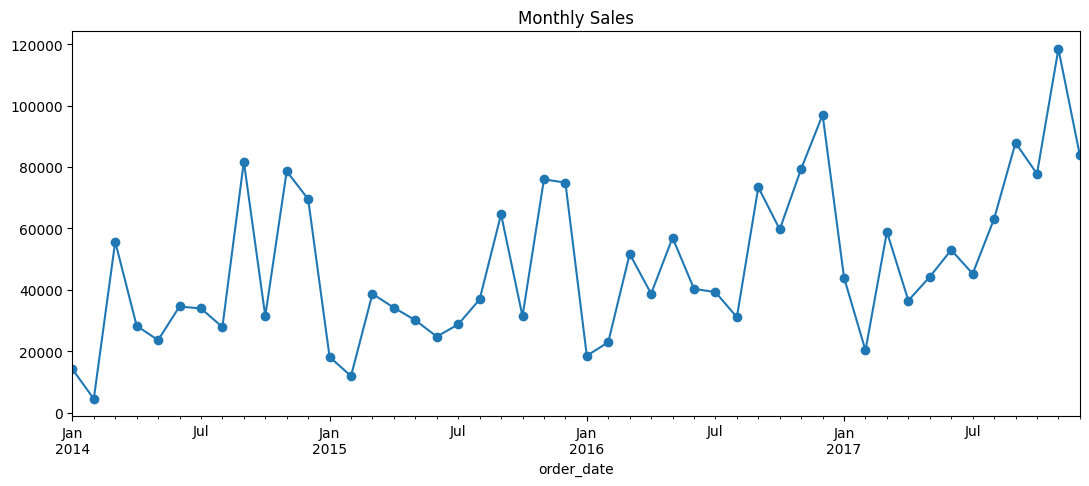

order_date
2017-08-01     63120.8880
2017-09-01     87866.6520
2017-10-01     77776.9232
2017-11-01    118447.8250
2017-12-01     83829.3188
Freq: MS, Name: sales, dtype: float64

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

plt.rcParams['figure.figsize'] = (13, 5)

df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['order_date'])
monthly = df.set_index('order_date').resample('MS')['sales'].sum()
monthly.plot(marker='o', title='Monthly Sales')
plt.show()
monthly.tail()

## 1. Train / test split (time-based, no shuffling)

In [9]:
TEST_MONTHS = 6
train, test = monthly[:-TEST_MONTHS], monthly[-TEST_MONTHS:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} months)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} months)")

Train: 2014-01-01 -> 2017-06-01  (42 months)
Test:  2017-07-01 -> 2017-12-01  (6 months)


## 2. Baseline — seasonal naive
Forecast each test month as the value from 12 months earlier (falls back to the last observed value if a full year of history isn't available).

In [10]:
def seasonal_naive_forecast(train_series, horizon, season_length=12):
    if len(train_series) >= season_length:
        base = train_series[-season_length:]
        reps = int(np.ceil(horizon / season_length))
        forecast = np.tile(base.values, reps)[:horizon]
    else:
        forecast = np.repeat(train_series.iloc[-1], horizon)
    return pd.Series(forecast, index=test.index)

baseline_forecast = seasonal_naive_forecast(train, TEST_MONTHS)
baseline_mape = mean_absolute_percentage_error(test, baseline_forecast)
baseline_rmse = np.sqrt(mean_squared_error(test, baseline_forecast))
print(f"Baseline (seasonal naive) — MAPE: {baseline_mape:.2%}, RMSE: {baseline_rmse:,.0f}")

Baseline (seasonal naive) — MAPE: 25.39%, RMSE: 23,430


## 3. SARIMA
A modest, defensible order is used — (1,1,1) x (1,1,1,12) — a good general-purpose starting point for monthly retail sales with yearly seasonality. Adjust based on ACF/PACF if you want to tune further.

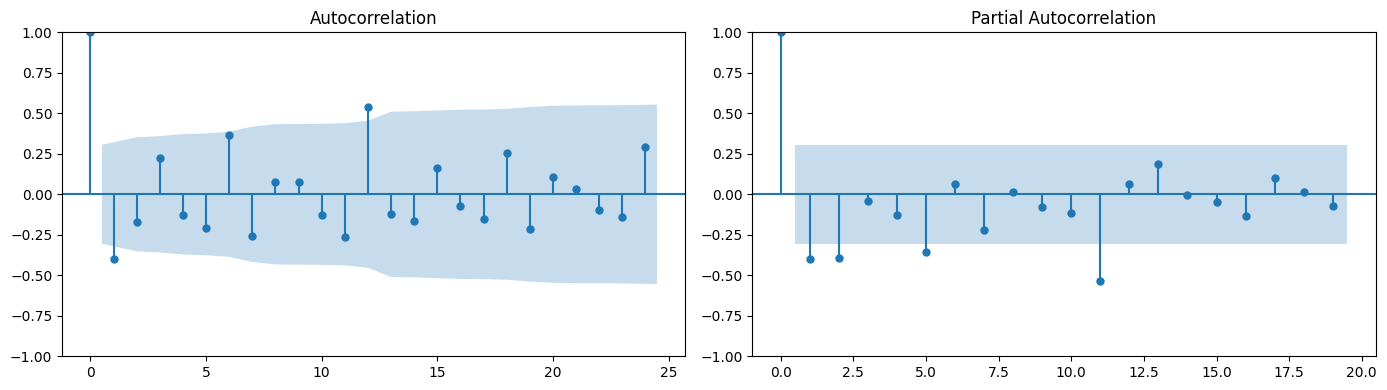

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train.diff().dropna(), ax=axes[0], lags=24)
plot_pacf(
    train.diff().dropna(),
    ax=axes[1],
    lags=min(24, len(train.diff().dropna()) // 2 - 1)
)
plt.tight_layout()
plt.show()

In [12]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -161.951
Date:                            Mon, 28 Sep 2026   AIC                            333.902
Time:                                    08:33:41   BIC                            337.443
Sample:                                01-01-2014   HQIC                           333.865
                                     - 06-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0300      0.651      0.046      0.963      -1.246       1.306
ma.L1         -0.8729      0.252   

In [13]:
sarima_forecast_obj = sarima_fit.get_forecast(steps=TEST_MONTHS)
sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

sarima_mape = mean_absolute_percentage_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
print(f"SARIMA — MAPE: {sarima_mape:.2%}, RMSE: {sarima_rmse:,.0f}")

SARIMA — MAPE: 17.40%, RMSE: 16,839


## 4. Holt-Winters (triple exponential smoothing)

In [14]:
hw_model = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12
).fit()
hw_forecast = hw_model.forecast(TEST_MONTHS)

hw_mape = mean_absolute_percentage_error(test, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
print(f"Holt-Winters — MAPE: {hw_mape:.2%}, RMSE: {hw_rmse:,.0f}")

Holt-Winters — MAPE: 17.12%, RMSE: 18,278


## 5. Model comparison

In [15]:
results = pd.DataFrame({
    'Model': ['Seasonal Naive (baseline)', 'SARIMA', 'Holt-Winters'],
    'MAPE': [baseline_mape, sarima_mape, hw_mape],
    'RMSE': [baseline_rmse, sarima_rmse, hw_rmse],
}).sort_values('MAPE')

best_model_name = results.iloc[0]['Model']
improvement_vs_baseline = (baseline_mape - results.iloc[0]['MAPE']) / baseline_mape

print(results.to_string(index=False))
print(f"\nBest model: {best_model_name}")
print(f"Improvement vs. baseline MAPE: {improvement_vs_baseline:.1%}")

                    Model     MAPE         RMSE
             Holt-Winters 0.171193 18278.010517
                   SARIMA 0.174033 16839.436269
Seasonal Naive (baseline) 0.253905 23430.161200

Best model: Holt-Winters
Improvement vs. baseline MAPE: 32.6%


## 6. Plot forecasts vs. actuals

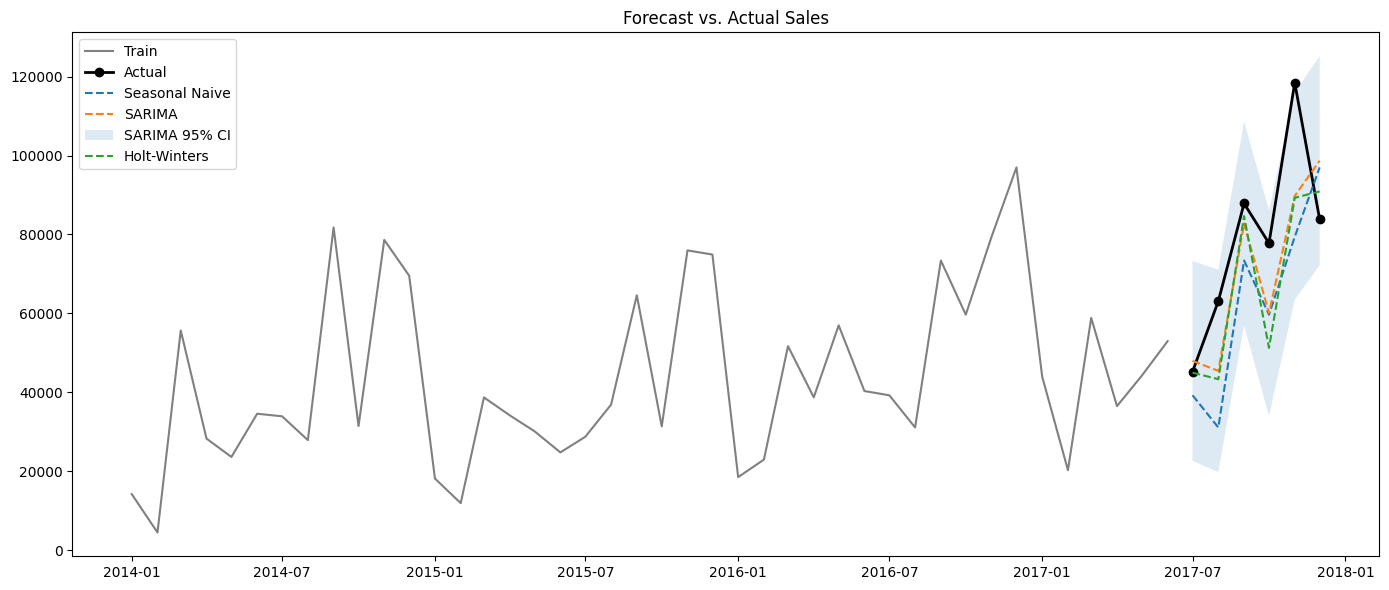

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Train', color='gray')
plt.plot(test.index, test.values, label='Actual', color='black', marker='o', linewidth=2)
plt.plot(test.index, baseline_forecast.values, label='Seasonal Naive', linestyle='--')
plt.plot(test.index, sarima_forecast.values, label='SARIMA', linestyle='--')
plt.fill_between(test.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.15, label='SARIMA 95% CI')
plt.plot(test.index, hw_forecast.values, label='Holt-Winters', linestyle='--')
plt.legend()
plt.title('Forecast vs. Actual Sales')
plt.tight_layout()
plt.savefig('../reports/figures/forecast_vs_actual.png', dpi=150)
plt.show()

## 7. Refit best model on full history and forecast forward

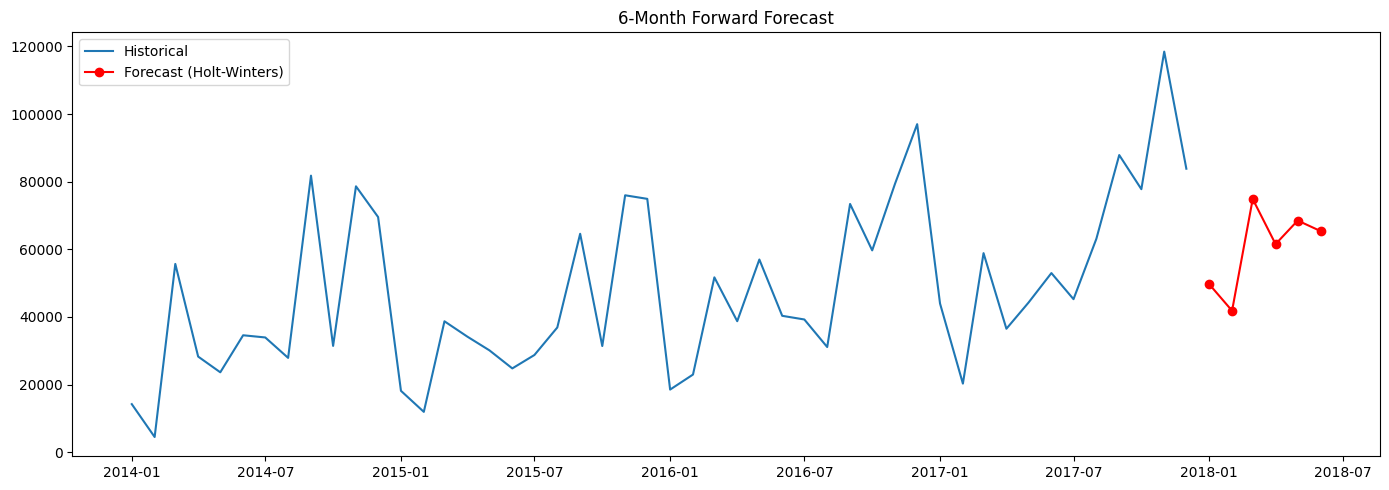

2018-01-01    49693.654720
2018-02-01    41839.975569
2018-03-01    74872.554375
2018-04-01    61537.825260
2018-05-01    68507.951543
2018-06-01    65394.613439
Freq: MS, dtype: float64

In [17]:
FORECAST_HORIZON = 6

if best_model_name == 'SARIMA':
    final_model = SARIMAX(monthly, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    future_forecast = final_model.get_forecast(steps=FORECAST_HORIZON).predicted_mean
elif best_model_name == 'Holt-Winters':
    final_model = ExponentialSmoothing(monthly, trend='add', seasonal='add', seasonal_periods=12).fit()
    future_forecast = final_model.forecast(FORECAST_HORIZON)
else:
    future_forecast = seasonal_naive_forecast(monthly, FORECAST_HORIZON)

future_index = pd.date_range(monthly.index[-1] + pd.DateOffset(months=1), periods=FORECAST_HORIZON, freq='MS')
future_forecast.index = future_index

plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, label='Historical')
plt.plot(future_forecast.index, future_forecast.values, label=f'Forecast ({best_model_name})', marker='o', color='red')
plt.legend()
plt.title(f'{FORECAST_HORIZON}-Month Forward Forecast')
plt.tight_layout()
plt.savefig('../reports/figures/forward_forecast.png', dpi=150)
plt.show()

future_forecast

## Summary
Fill these into the README once the notebook has been run end to end:
- Best model: **{best_model_name}**
- MAPE improvement vs. seasonal-naive baseline: **{improvement_vs_baseline:.1%}**
- Next 6 months' forecast: see the table above